### Identify encoder failures through time

Do EFD study of locations and frequency of each encoder (az and el) to determine problematic spots, and degradation rates before we have operational issues like this week. 

There are warning logmessages when encoders drop out, so it should be a simple matter to match those to the azimuth/elevation position then finally tape position.

In [1]:
%matplotlib widget
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from astropy.time import Time
from pathlib import Path
from datetime import datetime

from lsst.summit.utils.tmaUtils import (
    TMAEventMaker,
    TMAState,
)
from lsst.summit.utils.efdUtils import makeEfdClient, getEfdData

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

## Create Event Maker


In [3]:
event_maker = TMAEventMaker()
client = makeEfdClient()

In [4]:
# make a list of all topics in the EFD related to MTMount
topics = await client.get_topics()
for topic in topics:
    if 'MTMount' in topic:
        print(topic)

lsst.sal.MTMount.Camera_Cable_Wrap
lsst.sal.MTMount.Safety_System
lsst.sal.MTMount.ackcmd
lsst.sal.MTMount.auxiliaryBoxes
lsst.sal.MTMount.auxiliaryCabinetsThermal
lsst.sal.MTMount.azimuth
lsst.sal.MTMount.azimuthCableWrap
lsst.sal.MTMount.azimuthDrives
lsst.sal.MTMount.azimuthDrivesThermal
lsst.sal.MTMount.balancing
lsst.sal.MTMount.cabinet0101
lsst.sal.MTMount.cabinet0101Thermal
lsst.sal.MTMount.cameraCableWrap
lsst.sal.MTMount.capacitorBank
lsst.sal.MTMount.command_applySettingsSet
lsst.sal.MTMount.command_clearError
lsst.sal.MTMount.command_clearerror
lsst.sal.MTMount.command_closeMirrorCovers
lsst.sal.MTMount.command_disable
lsst.sal.MTMount.command_disableCameraCableWrapFollowing
lsst.sal.MTMount.command_disableCameraCableWrapTracking
lsst.sal.MTMount.command_enable
lsst.sal.MTMount.command_enableCameraCableWrapFollowing
lsst.sal.MTMount.command_enableCameraCableWrapTracking
lsst.sal.MTMount.command_enterControl
lsst.sal.MTMount.command_exitControl
lsst.sal.MTMount.command_homeBo

In [5]:
# Get all azimuth position and timestamp data within a particular time range
start = Time("2025-12-01T00:00:00Z", scale="utc")
end = Time("2025-12-01T23:59:00Z", scale="utc")

In [6]:
error = await client.select_time_series(
    "lsst.sal.MTMount.logevent_error", ["*"], start, end
)

In [7]:
error

,active,code,latched,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,subsystem,text
2025-12-01 01:26:08.361252+00:00,False,123,True,1.764552e+09,MTMount,1.764552e+09,13,0,55e39bfb,2841,1.764552e+09,0,VI chain: EIBManagement.lvlib:EIBManagementTMA...
2025-12-01 01:26:08.361793+00:00,True,702,True,1.764552e+09,MTMount,1.764552e+09,13,0,55e39bfb,2842,1.764552e+09,0,The available encoder heads do not allow to co...
2025-12-01 01:26:08.371328+00:00,False,160,True,1.764552e+09,MTMount,1.764552e+09,13,0,55e39bfb,2843,1.764552e+09,0,An error in EIB subsystem has ocurred
2025-12-01 01:26:30.633946+00:00,False,460,True,1.764552e+09,MTMount,1.764552e+09,13,0,55e39bfb,2844,1.764552e+09,0,An error in EIB subsystem has ocurred
2025-12-01 01:26:30.637900+00:00,True,401,True,1.764552e+09,MTMount,1.764552e+09,13,0,55e39bfb,2845,1.764552e+09,0,The softmotion axis went to fault
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-01 23:48:06.395526+00:00,False,56,True,1.764633e+09,MTMount,1.764633e+09,13,0,55e39bfb,3609,1.764633e+09,0,LabVIEW: (Hex 0x38) The network operation exce...
2025-12-01 23:48:28.538135+00:00,False,123,False,1.764633e+09,MTMount,1.764633e+09,13,0,55e39bfb,3610,1.764633e+09,0,VI chain: EIBManagement.lvlib:EIBManagementTMA...
2025-12-01 23:48:33.489362+00:00,False,460,False,1.764633e+09,MTMount,1.764633e+09,13,0,55e39bfb,3611,1.764633e+09,0,An error in EIB subsystem has ocurred
2025-12-01 23:49:04.065066+00:00,False,-8150,True,1.764633e+09,MTMount,1.764633e+09,13,0,55e39bfb,3612,1.764633e+09,0,VI chain: axesCommands.lvlib:commandReceiver.l...


text
Axis control algorith detected a fault. Posible causes are: NoNewData, Too Many Drives in Faul, AXESPXI and TMAPXI comm fault or software error. Check if NoNewData or PXIs comm alarms are active, otherwise this means drives fault                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

/tmp/ipykernel_8595/4113478867.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


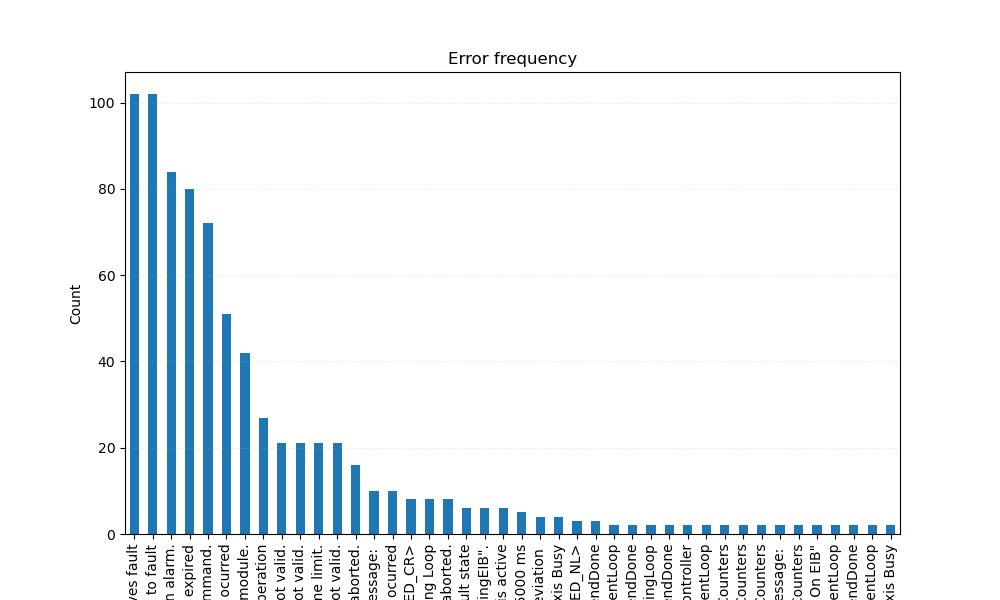

In [8]:
counts = error['text'].value_counts()

print(counts)

plt.figure(figsize=(10, 6))
counts.plot(kind='bar')

plt.xlabel("Error type")
plt.ylabel("Count")
plt.title("Error frequency")
plt.grid(axis="y", linestyle=":", alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
specific_error = """VI chain: Interpreter.lvlib:SplitString.vi:3850525 in RemoteVariableServer.lvlib:Task.vi.ACBRProxyCaller.4C500020->RemoteVariableServer.lvlib:Task.vi:5130002->RemoteVariableServer.lvlib:CreateVariableSubscriptionBinary.vi:5800003->RemoteVariableServer.lvlib:GetReadTaskVariablesInfoForBinary.vi:5120007<PARSED_NL> Description: LabVIEW: (Hex 0x2A) Generic error.<PARSED_NL>=========================<PARSED_NL>Custom:  Invalid equation!<PARSED_NL>=========================<PARSED_NL>Custom:  Faulty expression: "TMA_AZ_ENC_ELV_0001_ErrorStatus"<PARSED_NL>=========================<PARSED_NL>Custom:  Faulty Event: "Name: Elevation Encoder Head 1 lost. Area 700.EIB. Event type: "<PARSED_NL>=========================<PARSED_NL>Custom:  Faulty Event: "Name: Elevation Encoder Head 2 lost. Area 700.EIB. Event type: "<PARSED_NL>=========================<PARSED_NL>Custom:  Faulty Event: "Name: Elevation Encoder Head 3 lost. Area 700.EIB. Event type: "<PARSED_NL>=========================<PARSED_NL>Custom:  Faulty Event: "Name: Elevation Encoder Head 4 lost. Area 700.EIB. Event type: "<PARSED_NL>=========================<PARSED_NL>Custom:  Faulty Event: "Name: Azimuth Encoder Head 1 lost. Area 700.EIB. Event type: "<PARSED_NL>=========================<PARSED_NL>Custom:  Faulty Event: "Name: Azimuth Encoder Head 2 lost. Area 700.EIB. Event type: "<PARSED_NL>=========================<PARSED_NL>Custom:  Faulty Event: "Name: Azimuth Encoder Head 3 lost. Area 700.EIB. Event type: "<PARSED_NL>=========================<PARSED_NL>Custom:  Faulty Event: "Name: Azimuth Encoder Head 4 lost. Area 700.EIB. Event type: "<PARSED_NL>=========================<PARSED_NL>Origin:  TMA controller Event Handling Loop"""

In [10]:
tabla_error_VI_chain = error[ error['text'] == specific_error ]
print(tabla_error_VI_chain)

                                  active  code  latched  private_efdStamp  \
2025-12-01 04:19:01.819267+00:00   False    42     True      1.764563e+09   
2025-12-01 04:19:17.888976+00:00   False    42    False      1.764563e+09   
2025-12-01 04:39:44.308066+00:00   False    42     True      1.764564e+09   
2025-12-01 04:39:46.447552+00:00   False    42     True      1.764564e+09   
2025-12-01 04:39:46.966728+00:00   False    42     True      1.764564e+09   
2025-12-01 04:39:47.486017+00:00   False    42     True      1.764564e+09   
2025-12-01 04:39:47.996562+00:00   False    42     True      1.764564e+09   
2025-12-01 04:39:48.152230+00:00   False    42    False      1.764564e+09   

                                 private_identity  private_kafkaStamp  \
2025-12-01 04:19:01.819267+00:00          MTMount        1.764563e+09   
2025-12-01 04:19:17.888976+00:00          MTMount        1.764563e+09   
2025-12-01 04:39:44.308066+00:00          MTMount        1.764564e+09   
2025-12-01 04:

In [11]:
az = await client.select_time_series(
    "lsst.sal.MTMount.azimuth", ["actualPosition", "timestamp"], start, end
)

In [12]:
az.index = pd.to_datetime(az.index)
tabla_error_VI_chain.index = pd.to_datetime(tabla_error_VI_chain.index)

In [13]:
az['timestamp'] = pd.to_datetime(az['timestamp'], unit='s')
az.set_index('timestamp', inplace=True)

In [14]:
error_times = tabla_error_VI_chain.index

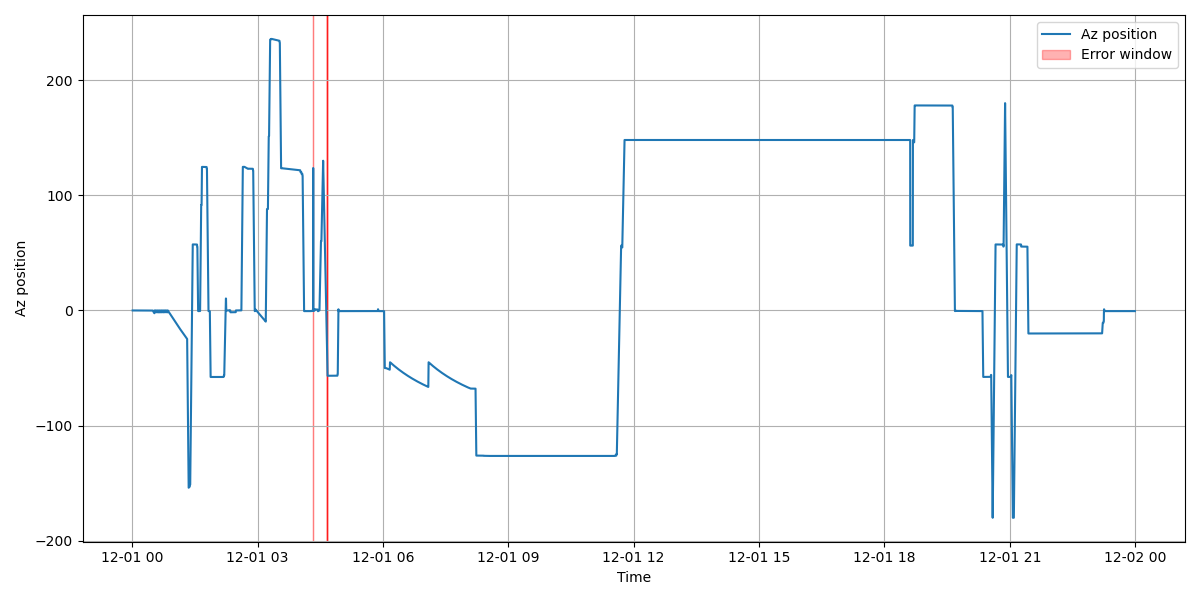

In [18]:
plt.figure(figsize=(12,6))
plt.plot(az.index, az['actualPosition'], label="Az position")

# Draw 3-second stripes around each error_time
for t in error_times:  
    plt.axvspan(t - pd.Timedelta(seconds=1.5),
                t + pd.Timedelta(seconds=1.5),
                color='red', alpha=0.3) 

plt.xlabel("Time")
plt.ylabel("Az position")
plt.grid()
plt.legend(["Az position", "Error window"])
plt.tight_layout()
plt.show()

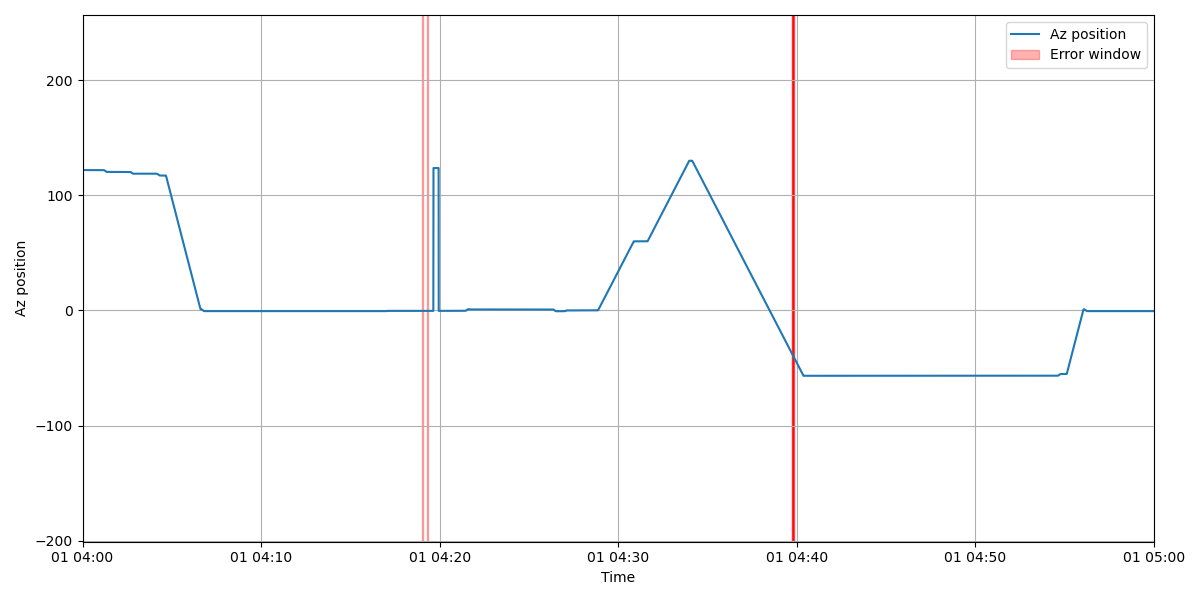

In [21]:
plt.figure(figsize=(12,6))
plt.plot(az.index, az['actualPosition'], label="Az position")

for t in error_times:
    plt.axvspan(t - pd.Timedelta(seconds=1.5),
                t + pd.Timedelta(seconds=1.5),
                color='red', alpha=0.3)

# Limit in time
start_time = az.index.normalize()[0] + pd.Timedelta(hours=4)  # initial time + 4h
end_time   = az.index.normalize()[0] + pd.Timedelta(hours=5)  # initial time + 5h
plt.xlim(start_time, end_time)

plt.xlabel("Time")
plt.ylabel("Az position")
plt.grid()
plt.legend(["Az position", "Error window"])
plt.tight_layout()
plt.show()

KeyError: "None of [DatetimeIndex(['2025-12-01 04:19:01.819267+00:00',\n               '2025-12-01 04:19:17.888976+00:00',\n               '2025-12-01 04:39:44.308066+00:00',\n               '2025-12-01 04:39:46.447552+00:00',\n               '2025-12-01 04:39:46.966728+00:00',\n               '2025-12-01 04:39:47.486017+00:00',\n               '2025-12-01 04:39:47.996562+00:00',\n               '2025-12-01 04:39:48.152230+00:00'],\n              dtype='datetime64[ns, UTC]', freq=None)] are in the [index]"

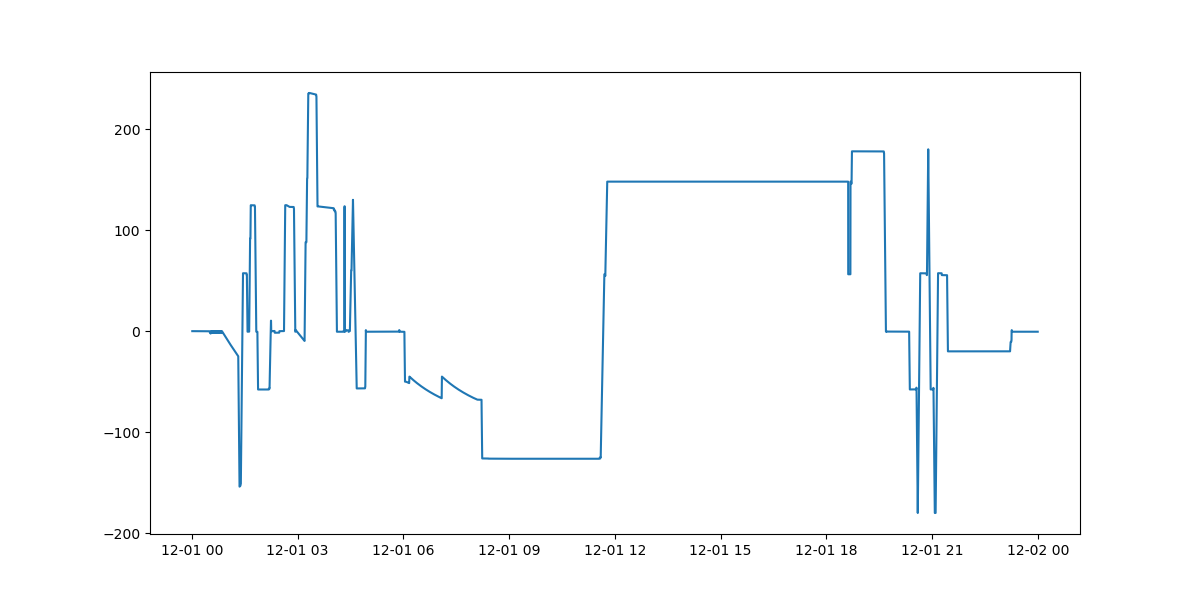

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

# Línea principal: posición
ax.plot(
    az.index,
    az['actualPosition'],
    color="blue",
    label="Actual Position"
)

# Añadir puntos en los tiempos donde ocurre error
ax.scatter(
    tabla_error_VI_chain.index,
    az.loc[tabla_error_VI_chain.index, 'actualPosition'],   # valores Y en esos instantes
    color="red",
    s=30,
    label="Error events"
)

ax.set_xlabel("Time")
ax.set_ylabel("Actual Position")
ax.set_title("Position vs Time with Error Events Marked")
ax.legend()
ax.grid(True)

In [ ]:
az

In [ ]:
el = await client.select_time_series(
    "lsst.sal.MTMount.elevation", ["actualPosition", "timestamp"], start, end
)

In [ ]:
times_az = [datetime.datetime.utcfromtimestamp(ts) for ts in az['timestamp']]
times_el = [datetime.datetime.utcfromtimestamp(ts) for ts in el['timestamp']]

fig, ax = plt.subplots()

ax.plot(
    times_az,
    az['actualPosition'],
    color="blue",
    label="Az",
)

ax.plot(
    times_el,
    el['actualPosition'],
    color="orange",
    label="El",
)

ax.legend(loc="lower left")
ax.grid(":", alpha=0.25)

# EJE X: Time
ax.set_xlabel("Time")

# EJE Y: vacío (sin texto)
ax.set_ylabel("")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M:%S"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

plt.gcf().autofmt_xdate()  # gira las fechas para que no se solapen

plt.tight_layout()
plt.show()

In [ ]:
encoder = await client.select_time_series(
    "lsst.sal.MTMount.encoder", ["*"], start, end
)

In [ ]:
encoder.columns